# Load Library

In [1]:
!pip install boto3 pandas matplotlib scipy scikit-learn tqdm nibabel optuna torch_geometric torch_cluster einops scikit-image medpy

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 251.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 246.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 278.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 155.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 149.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 152.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 122.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 249.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 384.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 264.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 102.4 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# -------------------------
# Core Python & Scientific
# -------------------------
import os 
import re
import math
import gc
import random
import itertools
import boto3
from collections import Counter
from torch_geometric.utils import add_self_loops
from torch_geometric.nn import GATv2Conv


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.widgets import Slider
from scipy.ndimage import distance_transform_edt
import scipy.ndimage

# -------------------------
# PyTorch Core
# -------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split
from torch.autograd import Variable
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts


# -------------------------
# Scikit-learn
# -------------------------
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# -------------------------
# Others
# -------------------------
from tqdm import tqdm
import nibabel as nib
from IPython.display import display
from concurrent.futures import ProcessPoolExecutor
from joblib import Parallel, delayed
import optuna
from optuna.samplers import TPESampler
from torch_geometric.nn import DynamicEdgeConv
from torch_geometric.nn import GATConv
from torch_cluster import radius_graph
from torch_geometric.data import Data, Batch  
from torch_geometric.nn import SAGEConv
from einops import rearrange


from torch_geometric.nn import global_mean_pool
from torch_geometric.nn.aggr import AttentionalAggregation
from torch_geometric.utils import to_dense_batch
from torch_geometric.nn.pool import global_max_pool
from torch_geometric.nn import radius_graph

import numpy as np
from skimage.segmentation import slic
from scipy.spatial.distance import cdist
from scipy import ndimage
import networkx as nx
import torch
import time
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [3]:
print(torch.__version__)
print(torch.version.cuda)

2.4.1+cu124
12.4


# Preprocessing

In [4]:
# ---------------- Preprocessing ----------------

def percentile_normalize(image, lower=0.5, upper=99.5):
    mask = image > 0
    if not mask.any():
        return image
    lo = np.percentile(image[mask], lower)
    hi = np.percentile(image[mask], upper)
    img = np.clip(image, lo, hi)
    return (img - img[mask].mean()) / (img[mask].std() + 1e-8)

def pad_depth(vol, target_depth=160):
    is_tensor = isinstance(vol, torch.Tensor)
    current_depth = vol.shape[-1]
    diff = current_depth - target_depth

    if diff == 0:
        return vol

    if diff > 0:
        front_crop = diff // 2
        back_crop = diff - front_crop
        return vol[..., front_crop:-back_crop]

    front_pad = (-diff) // 2
    back_pad = (-diff) - front_pad
    if is_tensor:
        return F.pad(vol, (front_pad, back_pad))
    else:
        return np.pad(vol, [(0, 0)] * (vol.ndim - 1) + [(front_pad, back_pad)], mode='constant')

def center_crop_xy(img, lbl, size=192):
    C, H, W, D = img.shape
    sh = (H - size) // 2
    sw = (W - size) // 2
    img = img[:, sh:sh + size, sw:sw + size, :]
    lbl = lbl[sh:sh + size, sw:sw + size, :]
    return img, lbl

# ---------------- Dataset ----------------

class BraTSSliceDataset(Dataset):
    def __init__(self, slice_index, feature_dir, target_dir,
                 modalities=['t1n', 't1c', 't2f', 't2w'],
                 crop_val=False, target_depth=144, debug_visual=False):
        self.slice_index = slice_index
        self.feature_dir = feature_dir
        self.target_dir = target_dir
        self.modalities = modalities
        self.crop_val = crop_val
        self.target_depth = target_depth
        self.debug_visual = debug_visual

    def __len__(self):
        return len(self.slice_index)

    def __getitem__(self, idx):
        sid, slice_idx = self.slice_index[idx]
        vols = []

        for m in self.modalities:
            path = os.path.join(self.feature_dir, f"{sid}__{sid}-{m}.nii.gz")
            img = nib.load(path).get_fdata()
            img = percentile_normalize(img)
            vols.append(img)

        image = np.stack(vols, axis=0)
        label_path = os.path.join(self.target_dir, f"{sid}__{sid}-seg.nii.gz")
        label = nib.load(label_path).get_fdata().astype(np.int64)

        image = pad_depth(image, self.target_depth)
        label = pad_depth(label, self.target_depth)

        if self.crop_val:
            image, label = center_crop_xy(image, label, size=self.crop_val)

        image_slice = torch.from_numpy(image[..., slice_idx]).float()
        label_slice = torch.from_numpy(label[..., slice_idx]).long()

        if self.debug_visual:
            self.visualize(image_slice, label_slice, sid, slice_idx)

        return image_slice, label_slice

    def visualize(self, image, label, sid, idx):
        import matplotlib.pyplot as plt
        fig, axs = plt.subplots(1, 2, figsize=(8, 4))
        axs[0].imshow(label.numpy(), cmap='gray')
        axs[0].set_title(f"GT Label: {sid} [{idx}]")
        axs[1].imshow(image[0].numpy(), cmap='gray')
        axs[1].set_title(f"Modality 0: {sid}")
        plt.tight_layout()
        plt.show()

# ---------------- Split Function ----------------

def get_train_val_datasets(feature_dir, target_dir,
                           slice_train_ratio=0.8,
                           tumor_ratio=0.7,
                           crop_val=False, target_depth=144,
                           debug_visual=False, limit_subjects=None, seed=42):
    all_files = os.listdir(feature_dir)
    subjs = sorted({f.split('__')[0] for f in all_files if f.endswith('.nii.gz')})
    if limit_subjects:
        subjs = subjs[:limit_subjects]

    all_slices = []

    tumor_slices = []
    non_tumor_slices = []

    print("[Slice Indexing] Scanning all slices...")
    for sid in subjs:
        label_path = os.path.join(target_dir, f"{sid}__{sid}-seg.nii.gz")
        label = nib.load(label_path).get_fdata().astype(np.int64)
        label = pad_depth(label, target_depth)

        for d in range(label.shape[-1]):
            slice_lbl = label[..., d]
            entry = (sid, d)
            all_slices.append(entry)
            if np.any(slice_lbl > 0):
                tumor_slices.append(entry)
            else:
                non_tumor_slices.append(entry)

    # Shuffle once
    random.seed(seed)
    random.shuffle(all_slices)

    # Slice-based split (not subject)
    total_slices = len(all_slices)
    num_train = int(slice_train_ratio * total_slices)

    train_index_full = all_slices[:num_train]
    val_index = all_slices[num_train:]

    # Now filter train_index by tumor_ratio
    tumor_train = [x for x in train_index_full if x in tumor_slices]
    non_tumor_train = [x for x in train_index_full if x in non_tumor_slices]

    desired_tumor = int(tumor_ratio * num_train)
    desired_non_tumor = num_train - desired_tumor

    train_index = tumor_train[:desired_tumor] + non_tumor_train[:desired_non_tumor]
    random.shuffle(train_index)

    print(f"Total slices: {total_slices}")
    print(f"Train slices: {len(train_index)} (Tumor ratio: {tumor_ratio})")
    print(f"Val slices:   {len(val_index)} (unfiltered)")

    train_ds = BraTSSliceDataset(train_index, feature_dir, target_dir,
                                 crop_val=crop_val, target_depth=target_depth,
                                 debug_visual=debug_visual)
    val_ds = BraTSSliceDataset(val_index, feature_dir, target_dir,
                               crop_val=crop_val, target_depth=target_depth,
                               debug_visual=debug_visual)

    return train_ds, val_ds


In [5]:
feature_dir = "/workspace/BraTS_features"
target_dir  = "/workspace/BraTS_target"

training_dataset, validation_dataset = get_train_val_datasets(
    feature_dir, target_dir,
    slice_train_ratio=0.8,
    limit_subjects=2,
    seed=42000
)

print("Train samples:", len(training_dataset))
print("Val samples:", len(validation_dataset))



[Slice Indexing] Scanning all slices...
Total slices: 288
Train slices: 157 (Tumor ratio: 0.5)
Val slices:   58 (unfiltered)
Train samples: 157
Val samples: 58


In [6]:
tumor_count = 0
non_tumor_count = 0

for _, label_slice in tqdm(validation_dataset, desc="Counting"):
    if (label_slice > 0).any():
        tumor_count += 1
    else:
        non_tumor_count += 1

print(f"Tumor slices:     {tumor_count}")
print(f"Non-tumor slices: {non_tumor_count}")
print(f"Total:            {tumor_count + non_tumor_count}")


Counting: 100%|██████████| 58/58 [01:36<00:00,  1.66s/it]

Tumor slices:     8
Non-tumor slices: 50
Total:            58


In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=3,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False
)

imgs, lbls = next(iter(train_loader))
print("Input shape: ", imgs.shape)  
print("Label shape:", lbls.shape)   

imgs, lbls = next(iter(val_loader))
print("Input shape: ", imgs.shape)  
print("Label shape:", lbls.shape)

NameError: name 'train_dataset' is not defined

# Convert into graph

In [5]:
#Graph conversion 


def majority_vote(arr):
    values, counts = np.unique(arr, return_counts=True)
    return values[np.argmax(counts)]


def compute_quantiles(x):
    return np.quantile(x, [0.1, 0.25, 0.5, 0.75, 0.9])


def summarize_modality(modality, labels, n_segments):
    return np.stack([
        compute_quantiles(modality[labels == i]) if np.any(labels == i) else np.zeros(5)
        for i in range(n_segments)
    ], axis=0)


def analyze_regions(sv_map, image_data, ground_truth, n_segments):
    if image_data.ndim == 3:
        summaries = [
            summarize_modality(image_data[..., i], sv_map, n_segments)
            for i in range(image_data.shape[-1])
        ]
        node_features = np.concatenate(summaries, axis=-1)
    else:
        node_features = summarize_modality(image_data, sv_map, n_segments)

    region_labels = np.array([
        majority_vote(ground_truth[sv_map == i]) if np.any(sv_map == i) else 0
        for i in range(n_segments)
    ])

    centers = np.array(ndimage.center_of_mass(np.ones_like(sv_map), sv_map, range(n_segments)))
    return node_features, centers, region_labels


def filter_invalid_regions(sv_map, features, centers, labels, n_segments):
    baseline = np.min(features[:, 4]) + 0.01
    valid = features[:, 4] >= baseline

    mapping = -np.ones(n_segments, dtype=np.int16)
    next_index = 0
    for i in range(n_segments):
        if valid[i]:
            mapping[i] = next_index
            next_index += 1

    updated_map = mapping[sv_map]
    return updated_map, features[valid], centers[valid], labels[valid]


def extract_graph_components(sv_map, image_data, ground_truth, n_segments):
    feats, centers, lbls = analyze_regions(sv_map, image_data, ground_truth, n_segments)
    return filter_invalid_regions(sv_map, feats, centers, lbls, n_segments)


def generate_knn_adjacency(centers, features, k, weighted=True, strict=True):
    pos_dists = cdist(centers, centers)
    adjacency = np.zeros_like(pos_dists)

    if strict:
        for i in range(len(pos_dists)):
            neighbors = np.argsort(pos_dists[i])[1:k+1]
            adjacency[i, neighbors] = 1
            adjacency[neighbors, i] = 1
    else:
        for i in range(len(pos_dists)):
            neighbors = np.argsort(pos_dists[i])[:k]
            adjacency[i, neighbors] = 1

    if weighted:
        feat_dists = cdist(features, features)
        feat_dists /= feat_dists.max()
        sigma = 0.1
        weights = np.exp(-feat_dists ** 2 / (2 * sigma ** 2))
        return adjacency * weights

    return adjacency


def spatial_adjacency(region_map, n_nodes, return_matrix=False):
    region_map = region_map.copy()
    region_map[region_map == -1] = n_nodes
    tmp = np.zeros((n_nodes + 1, n_nodes + 1), dtype=bool)

    if region_map.ndim == 3:
        for axis in range(3):
            slices = [slice(None)] * 3
            slices[axis] = slice(1, None)
            a = region_map[tuple(slices)]
            slices[axis] = slice(None, -1)
            b = region_map[tuple(slices)]
            tmp[a[a != b], b[a != b]] = True
    else:
        a, b = region_map[:-1, :], region_map[1:, :]
        tmp[a[a != b], b[a != b]] = True
        a, b = region_map[:, :-1], region_map[:, 1:]
        tmp[a[a != b], b[a != b]] = True

    adj = (tmp | tmp.T)[:-1, :-1]
    np.fill_diagonal(adj, True)
    if return_matrix:
        return adj
    return np.where(adj)


def convert_image_to_graph(image_data, label_map=None, target_segments=5000, slic_compactness=0.5, neighbors=10):
    from packaging import version
    from skimage import __version__ as skimage_version

    has_gt = label_map is not None
    if not has_gt:
        label_map = np.zeros(image_data.shape[:2], dtype=np.int16)

    is_multichannel = image_data.ndim == 3
    skimage_args = {
        'image': image_data.astype(np.float64),
        'n_segments': target_segments,
        'sigma': 1,
        'compactness': slic_compactness,
        'convert2lab': False,
        'start_label': 0
    }

    if version.parse(skimage_version) >= version.parse("0.19"):
        skimage_args['channel_axis'] = -1 if is_multichannel else None
    else:
        skimage_args['multichannel'] = is_multichannel

    regions = slic(**skimage_args).astype(np.int16)
    n_regions = regions.max() + 1

    new_map, features, centers, labels = extract_graph_components(regions, image_data, label_map, n_regions)

    if neighbors:
        adj = generate_knn_adjacency(centers, features, neighbors, weighted=False, strict=True)
    else:
        adj = spatial_adjacency(new_map, len(labels), return_matrix=True)

    G = nx.from_numpy_array(adj)
    for i in G.nodes:
        G.nodes[i]['features'] = features[i].tolist()
        if has_gt:
            G.nodes[i]['label'] = int(labels[i])
        G.nodes[i]['pos'] = (centers[i][1], centers[i][0])  # (x, y)

    return G, features, image_data, new_map, label_map


def batch_graph_conversion(batch_images, batch_labels, **kwargs):
    from joblib import Parallel, delayed

    def process_slice(i):
        img_np = batch_images[i].permute(1, 2, 0).numpy()  # (4, H, W) -> (H, W, 4)
        lbl_np = batch_labels[i].numpy()
        return convert_image_to_graph(img_np, lbl_np, **kwargs)

    results = Parallel(n_jobs=-1)(
        delayed(process_slice)(i) for i in range(batch_images.shape[0])
    )

    return [(G, new_map, image_data, label_map) for (G, _, image_data, new_map, label_map) in results]



def visualize_graph_over_superpixels(image_slice, superpixel_map, graph, segmentation=None, ax=None):
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    # Left: Ground truth
    if segmentation is not None:
        axs[0].imshow(segmentation, cmap='tab10', vmin=0, vmax=3)
        axs[0].set_title("Ground Truth Segmentation")
    else:
        axs[0].imshow(np.zeros_like(superpixel_map), cmap='gray')
        axs[0].set_title("No Ground Truth")

    axs[0].axis('off')

    # Right: Graph over superpixels
    axs[1].imshow(superpixel_map, cmap='nipy_spectral', alpha=0.4)

    pos = {i: (graph.nodes[i]['pos'][0], graph.nodes[i]['pos'][1]) for i in graph.nodes if 'pos' in graph.nodes[i]}

    if 'label' in next(iter(graph.nodes(data=True)))[1]:
        node_colors = [graph.nodes[i]['label'] for i in graph.nodes]
        cmap = plt.colormaps.get_cmap('tab10')
        nx.draw_networkx_nodes(graph, pos, ax=axs[1], node_size=30, node_color=node_colors, cmap=cmap)
    else:
        nx.draw_networkx_nodes(graph, pos, ax=axs[1], node_size=30, node_color='blue')

    nx.draw_networkx_edges(graph, pos, ax=axs[1], alpha=0.5)
    axs[1].set_title("Graph over SLIC Superpixels")
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()


In [6]:
# Load dataset
feature_dir = "/workspace/BraTS_features"
target_dir = "/workspace/BraTS_target"

train_ds, val_ds = get_train_val_datasets(feature_dir, target_dir, slice_train_ratio=0.85,
    limit_subjects=80,
    seed=420, crop_val = 160
)


# Wrap in DataLoader
train_loader = DataLoader(train_ds, batch_size=5, shuffle=True, num_workers=5, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=5, pin_memory=True)


# Convert into graph images
all_graphs = []
for batch_images, batch_labels in tqdm(train_loader, desc="Converting to Graphs (train set)", leave=True):
    graphs = batch_graph_conversion(
        batch_images,
        batch_labels,
        target_segments=4000,
        slic_compactness=0.4,
        neighbors=11
    )
    all_graphs.extend(graphs)


val_graphs = []
for batch_images, batch_labels in tqdm(val_loader, desc="Converting to Graphs (val set)", leave=True):
    graphs = batch_graph_conversion(batch_images, batch_labels,
                                     target_segments=4000,
                                     slic_compactness=0.4,
                                     neighbors=11)
    val_graphs.extend(graphs)




[Slice Indexing] Scanning all slices...
Total slices: 11520
Train slices: 5403 (Tumor ratio: 0.7)
Val slices:   1728 (unfiltered)


Converting to Graphs (val set): 100%|██████████| 432/432 [11:23<00:00,  1.58s/it]


In [8]:
def pyg_from_networkx(G):
    # Extract node features
    features = [data['features'] for _, data in G.nodes(data=True)]
    x = torch.tensor(features, dtype=torch.float)

    # Extract node labels (optional)
    if all('label' in data for _, data in G.nodes(data=True)):
        labels = [data['label'] for _, data in G.nodes(data=True)]
        y = torch.tensor(labels, dtype=torch.long)
    else:
        y = None

    # Extract edge_index
    edge_list = list(G.edges)
    if len(edge_list) == 0:
        # Fallback: add self-loop edges to avoid empty edge_index error
        edge_index = torch.arange(len(G.nodes), dtype=torch.long).repeat(2, 1)
    else:
        edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
        if not G.is_directed():
            edge_index = torch.cat([edge_index, edge_index[[1, 0]]], dim=1)

    # Build PyG Data object
    data = Data(x=x, edge_index=edge_index)
    if y is not None:
        data.y = y

    return data


In [9]:
# all_graphs = [(G_nx, sv_map, gt_seg), ...] for 30 slices
pyg_train_dataset = []
graph_train_tuples = []

for G_nx, sv_map, raw_mri, gt_voxel in all_graphs:
    pyg_train_dataset.append(pyg_from_networkx(G_nx))
    graph_train_tuples.append((G_nx, sv_map, raw_mri, gt_voxel))

# Confirm it's 30 graphs
print(f"Converted to PyG dataset: {len(pyg_train_dataset)} graphs")

print(pyg_train_dataset[0])
# ➜ Data(x=[num_nodes, in_feats], edge_index=[2, num_edges], y=[num_nodes])


Converted to PyG dataset: 5403 graphs
Data(x=[41, 20], edge_index=[2, 530], y=[41])


In [10]:
from torch_geometric.loader import DataLoader as PyGDataLoader

pyg_train_loader = PyGDataLoader(pyg_train_dataset, batch_size=4, shuffle=True)

for batch in pyg_train_loader:
    print(batch)
    print("x:", batch.x.shape)           # e.g., [total_nodes_in_batch, 20]
    print("y:", batch.y.shape)           # e.g., [total_nodes_in_batch]
    print("edge_index:", batch.edge_index.shape)  # e.g., [2, total_edges]
    print("batch (graph_id):", batch.batch.shape)  # e.g., [total_nodes_in_batch]
    break

pyg_val_dataset = []
graph_val_tuples = []

for G_nx, sv_map, raw_mri, gt_voxel in val_graphs:
    pyg_val_dataset.append(pyg_from_networkx(G_nx))
    graph_val_tuples.append((G_nx, sv_map, raw_mri, gt_voxel))

pyg_val_loader = PyGDataLoader(pyg_val_dataset, batch_size=4, shuffle=False)

DataBatch(x=[6064, 20], edge_index=[2, 72418], y=[6064], batch=[6064], ptr=[5])
x: torch.Size([6064, 20])
y: torch.Size([6064])
edge_index: torch.Size([2, 72418])
batch (graph_id): torch.Size([6064])


# Model

In [11]:
class GATModel(nn.Module):
    def __init__(self,
                 in_feats,
                 hidden_dims,
                 out_classes,
                 heads,
                 residuals=True,
                 layer_norm=True,
                 dropout=0.3,
                 attn_drop=0.2,
                 activation=F.elu):
        super(GATModel, self).__init__()

        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList() if layer_norm else None
        self.residuals = residuals
        self.layer_norm = layer_norm
        self.activation = activation
        self.dropout = dropout

        # First GATv2 layer
        self.layers.append(GATv2Conv(in_feats, hidden_dims[0], heads[0], dropout=attn_drop))
        if self.layer_norm:
            self.norms.append(nn.LayerNorm(hidden_dims[0] * heads[0]))

        # Hidden GATv2 layers
        for i in range(1, len(hidden_dims)):
            in_dim = hidden_dims[i - 1] * heads[i - 1]
            self.layers.append(GATv2Conv(in_dim, hidden_dims[i], heads[i], dropout=attn_drop))
            if self.layer_norm:
                self.norms.append(nn.LayerNorm(hidden_dims[i] * heads[i]))

        # Final output layer
        in_dim = hidden_dims[-1] * heads[-1]
        self.out_layer = GATv2Conv(in_dim, out_classes, heads=1, concat=False, dropout=0.0)

    def forward(self, g, features=None):
        x = g.x if features is None else features
        edge_index = g.edge_index

        # Add self-loops if not present (required by GATv2)
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))

        for i, layer in enumerate(self.layers):
            h = layer(x, edge_index)

            if self.residuals and h.shape == x.shape:
                h = h + x

            if self.layer_norm:
                h = self.norms[i](h)

            h = self.activation(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
            x = h

        out = self.out_layer(x, edge_index)
        return out


In [12]:
def node_dice_score(preds, targets, num_classes=4):
    """Computes Dice score for each class based on node labels."""
    dice_scores = []
    for cls in range(num_classes):
        pred_pos = preds == cls
        target_pos = targets == cls
        intersection = np.sum(pred_pos & target_pos)
        union = np.sum(pred_pos) + np.sum(target_pos)
        dice = (2 * intersection) / union if union > 0 else 1.0
        dice_scores.append(dice)
    return dice_scores

def project_graph_predictions_to_voxel(preds, superpixel_map):
    """
    Projects graph-level predictions to voxel space based on the SLIC superpixel map.
    
    preds: (N,) array of predicted labels for N graph nodes.
    superpixel_map: (H, W) or (D, H, W) integer array labeling superpixels.
    """
    output = np.zeros_like(superpixel_map)
    for label in range(len(preds)):
        output[superpixel_map == label] = preds[label]
    return output


def voxel_dice_score(pred_vox, true_vox, num_classes=4):
    scores = []
    for cls in range(num_classes):
        pred_mask = pred_vox == cls
        true_mask = true_vox == cls
        intersection = np.logical_and(pred_mask, true_mask).sum()
        union = pred_mask.sum() + true_mask.sum()
        dice = (2.0 * intersection) / union if union > 0 else 1.0
        scores.append(dice)
    return scores


In [13]:
class TverskyLoss(torch.nn.Module):
    def __init__(self, alpha=0.6, beta=0.4, smooth=1e-6):
        """
        alpha: controls false negatives (high alpha = penalize false negatives more)
        beta: controls false positives (high beta = penalize false positives more)
        """
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth

    def forward(self, logits, targets):
        """
        logits: (N, C) raw predictions from model
        targets: (N,) ground truth labels
        """
        num_classes = logits.shape[1]
        probs = F.softmax(logits, dim=1)
        one_hot = F.one_hot(targets, num_classes).float()

        dims = [0]  # over nodes

        TP = torch.sum(probs * one_hot, dim=dims)
        FP = torch.sum(probs * (1 - one_hot), dim=dims)
        FN = torch.sum((1 - probs) * one_hot, dim=dims)

        tversky = (TP + self.smooth) / (TP + self.alpha * FN + self.beta * FP + self.smooth)
        return 1 - tversky.mean()

class GNNSegmentationLoss(torch.nn.Module):
    def __init__(self, class_weights=None, alpha=0.5, beta=0.5, ce_weight=0.5):
        super().__init__()
        self.ce = torch.nn.CrossEntropyLoss(weight=class_weights)
        self.tversky = TverskyLoss(alpha=alpha, beta=beta)
        self.w = ce_weight  # weight for ce

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        tv_loss = self.tversky(logits, targets)
        return (self.w) * ce_loss +  tv_loss


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

in_feats = 20
hidden_dims = [64, 64]         # Important: GAT uses [out_channels per head]
out_classes = 4

gnn_model = GATModel(
    in_feats=in_feats,
    hidden_dims=hidden_dims,
    out_classes=out_classes,
    heads=[4, 4],
    residuals=True,
    layer_norm=True,
    dropout=0.3,
    attn_drop=0.2
).to(device)

# ---------- Config ----------
lr = 1e-4
weight_decay = 1e-4
T_0 = 10  # Epochs before restart
T_mult = 2
eta_min = 1e-5

# ---------- Optimizer + Scheduler ----------
optimizer = AdamW(gnn_model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=T_0, T_mult=T_mult, eta_min=eta_min)

# ---------- AMP Scaler ----------
scaler = GradScaler()



loss_fn = GNNSegmentationLoss().to(device)  # adjust weights if needed


In [15]:
def train_one_epoch(model, data_loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    progress = tqdm(data_loader, desc="Training", leave=False)
    for batch in progress:
        batch = batch.to(device)
        optimizer.zero_grad()

        logits = model(batch)              # [num_nodes, num_classes]
        labels = batch.y                  # [num_nodes]
        loss = loss_fn(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        all_preds.append(logits.argmax(dim=1).detach().cpu())
        all_labels.append(labels.detach().cpu())
        progress.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(data_loader)
    return avg_loss, torch.cat(all_preds), torch.cat(all_labels)


In [16]:
def calculate_node_dices(preds, labels, num_classes=None):
    """
    Calculates Dice score for each class.
    Always returns num_classes scores.
    """
    from sklearn.metrics import f1_score
    if num_classes is None:
        num_classes = np.max(labels) + 1

    dice_scores = []
    for cls in range(num_classes):
        pred_cls = (preds == cls).astype(int)
        label_cls = (labels == cls).astype(int)
        if np.sum(label_cls) == 0:
            dice_scores.append(0.0)  # instead of skip
            continue
        score = f1_score(label_cls, pred_cls)
        dice_scores.append(score)
    return dice_scores

    
def evaluate_gnn(model, data_loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Validating", leave=False):
            batch = batch.to(device)

            logits = model(batch)              # [num_nodes, num_classes]
            labels = batch.y                  # [num_nodes]
            loss = loss_fn(logits, labels)

            total_loss += loss.item()
            all_preds.append(logits.argmax(dim=1).detach().cpu())
            all_labels.append(labels.detach().cpu())

    avg_loss = total_loss / len(data_loader)
    preds = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    dice = calculate_node_dices(preds, labels)

    return avg_loss, list(dice)


# Train/Val

In [ ]:
num_epochs = 10
best_dice_mean = -1.0
best_model_state = None
best_epoch = -1


for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    train_loss, _, _ = train_one_epoch(gnn_model, pyg_train_loader, optimizer, loss_fn, device)
    val_loss, val_dice = evaluate_gnn(gnn_model, pyg_val_loader, loss_fn, device)  # val_dice: list or tensor of dice scores
    
    dice_mean = float(torch.tensor(val_dice).mean())  # Convert to mean

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Mean Dice: {dice_mean:.4f} | Per-Class Dice: {[f'{d:.4f}' for d in val_dice]}")

    if dice_mean > best_dice_mean:
        best_dice_mean = dice_mean
        best_model_state = gnn_model.state_dict()
        best_epoch = epoch + 1

# Load best model by mean Dice
gnn_model.load_state_dict(best_model_state)
print(f"\nRestored best model from epoch {best_epoch} with Mean Dice: {best_dice_mean:.4f}")



Epoch 1/10


Train Loss: 0.5744 | Val Loss: 0.6095 | Mean Dice: 0.7276 | Per-Class Dice: ['0.9957', '0.2752', '0.8132', '0.8263']

Epoch 2/10


Train Loss: 0.5299 | Val Loss: 0.5982 | Mean Dice: 0.7639 | Per-Class Dice: ['0.9954', '0.4259', '0.7944', '0.8397']

Epoch 3/10


Training:  26%|██▋       | 357/1351 [00:09<00:31, 31.83it/s, loss=0.76] 

# Reprojection / Refinement part

In [20]:
def project_nodes_to_voxels(sv_map, pred_nodes):
    """
    Reprojects node predictions back to voxel space.
    sv_map: [H,W] supervoxel map (each pixel has node ID)
    pred_nodes: [num_nodes] predicted class per node
    Returns: [H,W] predicted class per voxel
    """
    output = np.zeros_like(sv_map, dtype=np.int32)
    for node_id in np.unique(sv_map):
        output[sv_map == node_id] = pred_nodes[node_id]
    return output


In [21]:
# 1. Setup for training
gnn_model.eval()
pyg_train2_dataset = [pyg_from_networkx(G) for G, _, _, _ in graph_train_tuples]
pyg_train2_loader = PyGDataLoader(pyg_train2_dataset, batch_size=4, shuffle=False)

gnn_train_outputs = []  # Stores (reprojected_voxel_map, raw_mri, gt_voxel)

# 2. Run GNN → node predictions → reproject
for batch_idx, batch in enumerate(pyg_train2_loader):
    batch = batch.to(device)
    logits = gnn_model(batch, batch.x)         # [total_nodes, num_classes]
    preds = logits.argmax(dim=1).cpu().numpy() # node-level predicted classes
    batch_ids = batch.batch.cpu().numpy()      # graph IDs for each node

    for i in np.unique(batch_ids):
        node_mask = batch_ids == i
        node_preds = preds[node_mask]

        # Match with the corresponding graph tuple
        graph_idx = batch_idx * pyg_train2_loader.batch_size + i
        _, sv_map, raw_mri, gt_voxel = graph_train_tuples[graph_idx]

        # Reproject to voxel space
        voxel_map = project_nodes_to_voxels(sv_map, node_preds)  # shape [H,W]
        gnn_out = torch.FloatTensor(voxel_map)                   # → [H,W]

        # Save tuple for UNet input later
        gnn_train_outputs.append((gnn_out, raw_mri, gt_voxel))  # all are 2D slices


In [22]:
# 1. Setup for Validation
gnn_model.eval()

pyg_val2_dataset = [pyg_from_networkx(G) for G, _, _, _ in graph_val_tuples]
pyg_val2_loader = PyGDataLoader(pyg_val2_dataset, batch_size=4, shuffle=False)

gnn_val_outputs = []  # Stores (reprojected_voxel_map, raw_mri, gt_voxel)

# 2. Run GNN → node predictions → reproject for each val graph
for batch_idx, batch in enumerate(pyg_val2_loader):
    batch = batch.to(device)
    logits = gnn_model(batch, batch.x)         # [total_nodes, num_classes]
    preds = logits.argmax(dim=1).cpu().numpy() # node-level predicted classes
    batch_ids = batch.batch.cpu().numpy()      # graph IDs for each node

    for i in np.unique(batch_ids):
        node_mask = batch_ids == i
        node_preds = preds[node_mask]

        # Match with corresponding graph tuple
        graph_idx = batch_idx * pyg_val2_loader.batch_size + i
        _, sv_map, raw_mri, gt_voxel = graph_val_tuples[graph_idx]

        # Reproject to voxel space
        voxel_map = project_nodes_to_voxels(sv_map, node_preds)  # shape [H,W]
        gnn_out = torch.FloatTensor(voxel_map)                   # → [H,W]

        # Save for UNet input
        gnn_val_outputs.append((gnn_out, raw_mri, gt_voxel))  # all are 2D slices


# Refinement Model

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def center_crop_to_match(source: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """
    Center-crop `source` spatially (H, W) to match `target`.
    If source is smaller, reflect-pad to fit.
    Shapes: [B, C, H, W]
    """
    _, _, Hs, Ws = source.shape
    _, _, Ht, Wt = target.shape
    dh = Hs - Ht
    dw = Ws - Wt
    if dh == 0 and dw == 0:
        return source

    # If larger: crop
    top = max(dh // 2, 0)
    left = max(dw // 2, 0)
    bottom = max(Hs - (top + Ht), 0)
    right  = max(Ws - (left + Wt), 0)
    cropped = source[:, :, top:Hs - bottom if bottom != 0 else Hs,
                           left:Ws - right  if right  != 0 else Ws]

    # If still smaller: pad
    pad_h = max(Ht - cropped.shape[2], 0)
    pad_w = max(Wt - cropped.shape[3], 0)
    if pad_h > 0 or pad_w > 0:
        pl = pad_w // 2
        pr = pad_w - pl
        pt = pad_h // 2
        pb = pad_h - pt
        cropped = F.pad(cropped, (pl, pr, pt, pb), mode="reflect")
    return cropped


# ----------------------- CBAM -----------------------
class CBAMBlock2D(nn.Module):
    """
    Convolutional Block Attention Module (2D)
    """
    def __init__(self, channels: int, reduction: int = 8, spatial_kernel: int = 7):
        super().__init__()
        mid = max(channels // reduction, 1)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.shared_mlp = nn.Sequential(
            nn.Conv2d(channels, mid, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid, channels, kernel_size=1, bias=False),
        )
        self.spatial = nn.Conv2d(2, 1, kernel_size=spatial_kernel,
                                 padding=spatial_kernel // 2, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Channel attention
        avg_out = self.shared_mlp(self.avg_pool(x))
        max_out = self.shared_mlp(self.max_pool(x))
        channel_attn = torch.sigmoid(avg_out + max_out)
        x = x * channel_attn

        # Spatial attention
        avg = torch.mean(x, dim=1, keepdim=True)
        maxv, _ = torch.max(x, dim=1, keepdim=True)
        spatial_attn = torch.sigmoid(self.spatial(torch.cat([avg, maxv], dim=1)))
        return x * spatial_attn


# ----------------------- Residual Conv Block -----------------------
class ResidualConvBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, use_cbam: bool = True):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.act = nn.ReLU(inplace=True)
        self.cbam = CBAMBlock2D(out_ch) if use_cbam else nn.Identity()
        self.res_proj = nn.Identity() if in_ch == out_ch else nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = self.res_proj(x)
        out = self.conv(x)
        out = out + identity
        out = self.act(out)
        out = self.cbam(out)
        return out


# ----------------------- Up Block -----------------------
class UpBlock(nn.Module):
    """
    upconv -> concat(skip) -> residual conv (+ CBAM)
    """
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int, use_cbam: bool = True):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.block = ResidualConvBlock(out_ch + skip_ch, out_ch, use_cbam=use_cbam)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.up(x)
        skip = center_crop_to_match(skip, x)
        x = torch.cat([x, skip], dim=1)
        return self.block(x)


# ----------------------- Bottleneck: ViT style -----------------------
class TransformerEncoder2DBottleneck(nn.Module):
    """
    Simple ViT-ish bottleneck: flatten spatial tokens, MHA + FFN.
    Keeps channels as embedding dim; learnable 2D positional embeddings.
    """
    def __init__(self, channels: int, num_layers: int = 2, nhead: int = 8,
                 dim_feedforward: int | None = None, dropout: float = 0.1):
        super().__init__()
        if dim_feedforward is None:
            dim_feedforward = channels * 4
        enc_layer = nn.TransformerEncoderLayer(
            d_model=channels, nhead=nhead,
            dim_feedforward=dim_feedforward, dropout=dropout,
            batch_first=True, activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.pos_embed: nn.Parameter | None = None
        self.dropout = nn.Dropout(dropout)

    def _init_pos(self, L: int, C: int, device):
        pe = nn.Parameter(torch.zeros(1, L, C, device=device))
        # safe init: normal_ is fine here
        nn.init.normal_(pe, std=0.02)
        return pe

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        tokens = x.flatten(2).transpose(1, 2)  # [B, HW, C]
        L = H * W
        if (self.pos_embed is None
            or self.pos_embed.shape[1] != L
            or self.pos_embed.shape[2] != C
            or self.pos_embed.device != x.device):
            self.pos_embed = self._init_pos(L, C, x.device)
        tokens = self.dropout(tokens + self.pos_embed)
        tokens = self.encoder(tokens)               # [B, HW, C]
        return tokens.transpose(1, 2).reshape(B, C, H, W)


# ----------------------- Bottleneck: tiny Swin-style -----------------------
class WindowAttention2D(nn.Module):
    """
    Non-shifted windowed multi-head attention over ws×ws patches (simple + fast).
    """
    def __init__(self, channels: int, nhead: int = 8, window_size: int = 7,
                 mlp_ratio: float = 4.0, dropout: float = 0.1):
        super().__init__()
        self.window_size = window_size
        self.attn = nn.MultiheadAttention(embed_dim=channels, num_heads=nhead,
                                          dropout=dropout, batch_first=True)
        hidden = int(channels * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(channels, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, channels), nn.Dropout(dropout),
        )
        self.norm1 = nn.LayerNorm(channels)
        self.norm2 = nn.LayerNorm(channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        ws = self.window_size
        pad_h = (ws - H % ws) % ws
        pad_w = (ws - W % ws) % ws
        if pad_h or pad_w:
            x = F.pad(x, (0, pad_w, 0, pad_h), mode="reflect")
            H += pad_h; W += pad_w

        # [B, C, Nh, ws, Nw, ws] -> [B*Nh*Nw, ws*ws, C]
        x_ = x.view(B, C, H // ws, ws, W // ws, ws) \
             .permute(0, 2, 4, 3, 5, 1).contiguous() \
             .view(B * (H // ws) * (W // ws), ws * ws, C)

        # Attn + MLP with pre-norm + residuals
        residual = x_
        attn_out, _ = self.attn(self.norm1(x_), self.norm1(x_), self.norm1(x_))
        x_ = residual + attn_out

        residual2 = x_
        x_ = self.mlp(self.norm2(x_))
        x_ = residual2 + x_

        # Back to [B, C, H, W]
        x_ = x_.view(B, H // ws, W // ws, ws, ws, C) \
             .permute(0, 5, 1, 3, 2, 4).contiguous() \
             .view(B, C, H, W)

        if pad_h or pad_w:
            x_ = x_[:, :, :H - pad_h, :W - pad_w]
        return x_


class SwinStyleBottleneck2D(nn.Module):
    """
    Tiny, simplified Swin-style: a few non-shifted window-attention blocks.
    """
    def __init__(self, channels: int, nhead: int = 8, window_size: int = 7,
                 num_blocks: int = 2, dropout: float = 0.1):
        super().__init__()
        self.blocks = nn.ModuleList([
            WindowAttention2D(channels, nhead=nhead, window_size=window_size, dropout=dropout)
            for _ in range(num_blocks)
        ])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for blk in self.blocks:
            x = x + blk(x)   # outer residual across window-MSA+MLP
        return x


# ----------------------- Refinement U-Net (2D) -----------------------
class RefinementUNet(nn.Module):
    """
    4-level residual U-Net with CBAM in conv blocks and attention bottleneck.
    `bottleneck_type`: "vit" (default) or "swin"
    """
    def __init__(self,
                 in_channels: int,
                 num_classes: int,
                 base_ch: int = 32,
                 bottleneck_type: str = "vit",
                 vit_layers: int = 2,
                 vit_heads: int = 8,
                 swin_heads: int = 8,
                 swin_window: int = 7):
        super().__init__()
        ch1, ch2, ch3, ch4 = base_ch, base_ch * 2, base_ch * 4, base_ch * 8

        # Encoder 
        self.enc1 = ResidualConvBlock(in_channels, ch1, use_cbam=True); self.down1 = nn.MaxPool2d(2)
        self.enc2 = ResidualConvBlock(ch1,        ch2, use_cbam=True); self.down2 = nn.MaxPool2d(2)
        self.enc3 = ResidualConvBlock(ch2,        ch3, use_cbam=True); self.down3 = nn.MaxPool2d(2)
        self.enc4 = ResidualConvBlock(ch3,        ch4, use_cbam=True); self.down4 = nn.MaxPool2d(2)

        # Bottleneck attention at H/16, W/16
        if bottleneck_type.lower() == "swin":
            self.bottleneck = SwinStyleBottleneck2D(ch4, nhead=swin_heads, window_size=swin_window)
        else:
            self.bottleneck = TransformerEncoder2DBottleneck(ch4, num_layers=vit_layers, nhead=vit_heads)

        # Decoder 
        self.up4 = UpBlock(ch4, ch4, ch3, use_cbam=True)  # with e4
        self.up3 = UpBlock(ch3, ch3, ch2, use_cbam=True)  # with e3
        self.up2 = UpBlock(ch2, ch2, ch1, use_cbam=True)  # with e2
        self.up1 = nn.ConvTranspose2d(ch1, ch1, kernel_size=2, stride=2)  # final up to H,W
        self.cat_reduce = nn.Conv2d(ch1 * 2, ch1, kernel_size=1, bias=False)  
        self.dec1 = ResidualConvBlock(ch1, ch1, use_cbam=True)

        # Head
        self.head = nn.Conv2d(ch1, num_classes, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Encoder
        e1 = self.enc1(x)
        x  = self.down1(e1)
        e2 = self.enc2(x)
        x  = self.down2(e2)
        e3 = self.enc3(x)
        x  = self.down3(e3)
        e4 = self.enc4(x)
        x  = self.down4(e4)

        # Bottleneck attention
        x = self.bottleneck(x)

        # Decoder
        x = self.up4(x, e4)
        x = self.up3(x, e3)
        x = self.up2(x, e2)
        x = self.up1(x)
        e1c = center_crop_to_match(e1, x)
        x = self.cat_reduce(torch.cat([x, e1c], dim=1))
        x = self.dec1(x)
        x = self.head(x)
        return x

In [24]:
def crop_to_match(tensor, target_shape):
    """Crops `tensor` symmetrically to match `target_shape` (C, H, W)."""
    _, h, w = tensor.shape
    _, h_t, w_t = target_shape

    crop_top = (h - h_t) // 2
    crop_bottom = crop_top + h_t
    crop_left = (w - w_t) // 2
    crop_right = crop_left + w_t

    return tensor[:, crop_top:crop_bottom, crop_left:crop_right]

def combine_logits_and_image(voxel_map, raw_mri):
    if isinstance(voxel_map, np.ndarray):
        voxel_map = torch.from_numpy(voxel_map)
    if isinstance(raw_mri, np.ndarray):
        raw_mri = torch.from_numpy(raw_mri)

    if voxel_map.ndim == 2:
        voxel_map = voxel_map.unsqueeze(0)  # → [1, H, W]

    if raw_mri.ndim == 3 and raw_mri.shape[-1] == 4:
        # Permute if channels are last → (H, W, C) → (C, H, W)
        raw_mri = raw_mri.permute(2, 0, 1)

    # Ensure spatial shapes match
    if voxel_map.shape[1:] != raw_mri.shape[1:]:
        target_shape = (
            1,
            min(voxel_map.shape[1], raw_mri.shape[1]),
            min(voxel_map.shape[2], raw_mri.shape[2]),
        )
        voxel_map = crop_to_match(voxel_map, target_shape)
        raw_mri = crop_to_match(raw_mri, target_shape)

    return torch.cat([raw_mri, voxel_map], dim=0)  # [5, H, W]


class UNetDataset(torch.utils.data.Dataset):
    def __init__(self, gnn_outputs):
        self.samples = gnn_outputs  # Each is (voxel_map, raw_mri, gt_seg)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        voxel_map, raw_mri, gt_seg = self.samples[idx]
        x = combine_logits_and_image(voxel_map, raw_mri)  # [5, H, W]
        y = torch.from_numpy(gt_seg).long() if isinstance(gt_seg, np.ndarray) else gt_seg
        return x, y


In [25]:
train_dataset = UNetDataset(gnn_train_outputs)
val_dataset = UNetDataset(gnn_val_outputs)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=4, shuffle=False)


In [26]:
def soft_dice_loss(logits, targets, smooth=1e-6):
    """
    logits: [B, C, H, W]
    targets: [B, H, W] with values in {0,1,2,3}
    """
    num_classes = logits.shape[1]
    probs = F.softmax(logits, dim=1)                     # [B, C, H, W]
    one_hot = F.one_hot(targets, num_classes)            # [B, H, W, C]
    one_hot = one_hot.permute(0, 3, 1, 2).float()        # [B, C, H, W]

    dims = (0, 2, 3)
    intersection = torch.sum(probs * one_hot, dims)
    union = torch.sum(probs + one_hot, dims)

    dice = (2. * intersection + smooth) / (union + smooth)
    return 1. - dice.mean()  # averaged over all classes


def combined_loss(logits, targets, ce_weight=0.5):
    """
    logits: [B, 4, H, W]
    targets: [B, H, W] with int labels 0-3
    """
    ce = F.cross_entropy(logits, targets)
    dice = soft_dice_loss(logits, targets)
    return dice + ce_weight * ce

@torch.no_grad()
def compute_per_class_dice(logits, targets, num_classes=4):
    probs = F.softmax(logits, dim=1)
    preds = probs.argmax(dim=1)
    one_hot_preds = F.one_hot(preds, num_classes).permute(0, 3, 1, 2).float()
    one_hot_targets = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()

    dices = []
    for c in range(num_classes):
        intersection = torch.sum(one_hot_preds[:, c] * one_hot_targets[:, c])
        union = torch.sum(one_hot_preds[:, c]) + torch.sum(one_hot_targets[:, c])
        dice = (2. * intersection + 1e-6) / (union + 1e-6)
        dices.append(dice.item())
    return dices  # list of length 4


# Train/Val

In [29]:
unet = RefinementUNet(in_channels=5, num_classes=4, base_ch=32, bottleneck_type="swin").to(device)
optimizer = torch.optim.Adam(unet.parameters(), lr=1e-4)


best_dice_mean = -1.0
best_epoch = -1
best_model_path = "best_unet_model.pth"

num_epochs = 40

for epoch in range(num_epochs):
    unet.train()
    total_train_loss = 0.0

    for batch in tqdm(train_loader, desc="Training", leave=True):
        inputs, targets = batch
        inputs = inputs.to(device)         # [B, 4, H, W]
        targets = targets.to(device)       # [B, H, W]

        logits = unet(inputs)              # [B, 4, H, W]
        loss = combined_loss(logits, targets).to(device)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # ---------------- Validation ----------------
    unet.eval()
    total_val_loss = 0.0
    all_dice = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validation", leave=True):
            inputs, targets = batch
            inputs = inputs.to(device)
            targets = targets.to(device)

            logits = unet(inputs)
            loss = combined_loss(logits, targets).to(device)

            total_val_loss += loss.item()
            dice = compute_per_class_dice(logits, targets)  # list of 4 dice scores
            all_dice.append(torch.tensor(dice))

    avg_val_loss = total_val_loss / len(val_loader)
    mean_dice = torch.stack(all_dice).mean(dim=0)          # shape [4]
    dice_mean = mean_dice.mean().item()                    # average of 4 dice scores

    # ---------------- Save Best ----------------
    if dice_mean > best_dice_mean:
        best_dice_mean = dice_mean
        best_epoch = epoch + 1
        torch.save(unet.state_dict(), best_model_path)
        print(f"Saved new best model at epoch {best_epoch} with Mean Dice: {best_dice_mean:.4f}")

    # ---------------- Logging ----------------
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print("Dice: " + ", ".join([f"Class {i}: {d:.4f}" for i, d in enumerate(mean_dice.tolist())]))

# ---------------- Final Summary ----------------
print(f"\nBest model was at epoch {best_epoch} with Mean Dice = {best_dice_mean:.4f}")


Validation: 100%|██████████| 14/14 [00:01<00:00, 12.31it/s]


Saved new best model at epoch 1 with Mean Dice: 0.6422

Epoch 1/40
Train Loss: 1.4390 | Val Loss: 1.4447
Dice: Class 0: 0.9956, Class 1: 1.0000, Class 2: 0.0000, Class 3: 0.5733


Validation: 100%|██████████| 14/14 [00:01<00:00, 12.34it/s]



Epoch 2/40
Train Loss: 1.3518 | Val Loss: 1.2675
Dice: Class 0: 0.9993, Class 1: 0.2857, Class 2: 0.0000, Class 3: 0.5537


Validation: 100%|██████████| 14/14 [00:01<00:00, 12.99it/s]


...


Epoch 38/40
Train Loss: 0.5096 | Val Loss: 0.6298
Dice: Class 0: 0.9999, Class 1: 1.0000, Class 2: 0.8640, Class 3: 0.9806


Validation: 100%|██████████| 14/14 [00:01<00:00, 11.03it/s]



Epoch 39/40
Train Loss: 0.5040 | Val Loss: 0.6333
Dice: Class 0: 0.9999, Class 1: 1.0000, Class 2: 0.8506, Class 3: 0.9776


Validation: 100%|██████████| 14/14 [00:01<00:00, 12.96it/s]


Epoch 40/40
Train Loss: 0.4946 | Val Loss: 0.6308
Dice: Class 0: 1.0000, Class 1: 1.0000, Class 2: 0.8538, Class 3: 0.9862

Best model was at epoch 16 with Mean Dice = 0.9660


# Testing and Visualization

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.data import Batch
from torch_geometric.utils import from_networkx as pyg_from_networkx


def visualize_full_pipeline(image_slice, gt_mask, gnn_model, unet_model, device, show=True):
    """
    image_slice: Tensor [C, H, W] (e.g., 4 MRI modalities)
    gt_mask: Tensor [H, W] (ground truth segmentation)
    """

    # ------------------- Step 1: Preprocess -------------------
    image_np = np.transpose(image_slice, (1, 2, 0))  # [H, W, C] for SLIC
    label_np = gt_mask  # already [H, W]

    # ------------------- Step 2: SLIC → Graph -------------------
    graph, features, _, slic_map, _ = convert_image_to_graph(
        image_data=image_np,
        label_map=label_np,
        target_segments=5000,
        slic_compactness=0.5,
        neighbors=10
    )

    # ------------------- Step 3: Graph → PyG Format -------------------
    data = pyg_from_networkx(graph)
    data.x = torch.tensor(features, dtype=torch.float32)
    data = data.to(device)

    # ------------------- Step 4: GNN Inference -------------------
    gnn_model.eval()
    with torch.no_grad():
        out = gnn_model(data)  # [num_nodes, num_classes]
        pred_nodes = out.argmax(dim=1).cpu().numpy()  # class per node

    # ------------------- Step 5: Reproject Node Predictions -------------------
    mask_gnn = np.zeros_like(slic_map, dtype=np.uint8)
    for node_id in range(len(pred_nodes)):
        mask_gnn[slic_map == node_id] = pred_nodes[node_id]

    # ------------------- Step 6: Prepare UNet Input -------------------
    input_unet = np.concatenate([image_np.transpose(2, 0, 1), mask_gnn[None]], axis=0)  # [C+1, H, W]
    input_unet_tensor = torch.tensor(input_unet).unsqueeze(0).to(device)  # [1, 5, H, W]

    # ------------------- Step 7: UNet Inference -------------------
    unet_model.eval()
    with torch.no_grad():
        logits = unet_model(input_unet_tensor)  # [1, num_classes, H, W]
        pred_mask = logits.argmax(dim=1).squeeze(0).cpu().numpy()  # [H, W]

    # ------------------- Step 8: Visualization -------------------
    if show:
        fig, axs = plt.subplots(1, 4, figsize=(20, 5))

        axs[0].imshow(image_np[..., 0], cmap='gray')
        axs[0].set_title("Input (Modality 0)")

        axs[1].imshow(mask_gnn, cmap='tab10', vmin=0, vmax=3)
        axs[1].set_title("GNN Prediction")

        axs[2].imshow(pred_mask, cmap='tab10', vmin=0, vmax=3)
        axs[2].set_title("UNet Refinement")

        axs[3].imshow(gt_mask, cmap='tab10', vmin=0, vmax=3)
        axs[3].set_title("Ground Truth")

        for ax in axs:
            ax.axis('off')
        plt.tight_layout()
        plt.show()

    return mask_gnn, pred_mask


In [31]:
import os
import nibabel as nib
import numpy as np
import torch
from torch.utils.data import Dataset

# ------------------------------- Constants -------------------------------

FEATURE_DIR = "/workspace/BraTS_features"
TARGET_DIR  = "/workspace/BraTS_target"
PATIENT_IDS = [f"BraTS-MEN-{i:05d}-000" for i in range(8, 14)]  # Patients 1–5

MODALITIES = ['t1n', 't1c', 't2f', 't2w']  # 4-channel input
DEPTH = 155  # Expected slice count per subject

# ------------------------------- Utils -------------------------------

def percentile_normalize(image, lower=0.5, upper=99.5):
    mask = image > 0
    if not mask.any():
        return image
    lo = np.percentile(image[mask], lower)
    hi = np.percentile(image[mask], upper)
    img = np.clip(image, lo, hi)
    return (img - img[mask].mean()) / (img[mask].std() + 1e-8)

# ------------------------------- Dataset Class -------------------------------

class Full3DSliceDataset(Dataset):
    def __init__(self, patient_ids, feature_dir, target_dir, modalities=['t1n', 't1c', 't2f', 't2w']):
        self.modalities = modalities
        self.feature_dir = feature_dir
        self.target_dir = target_dir
        self.patient_ids = patient_ids
        self.slice_index = []  # [(patient_id, slice_id)]

        for pid in self.patient_ids:
            for d in range(DEPTH):
                self.slice_index.append((pid, d))

    def __len__(self):
        return len(self.slice_index)

    def __getitem__(self, idx):
        pid, d = self.slice_index[idx]
        vols = []
        
        for mod in self.modalities:
            path = os.path.join(self.feature_dir, f"{pid}__{pid}-{mod}.nii.gz")
            img = nib.load(path).get_fdata()
            img = percentile_normalize(img)
            vols.append(img[..., d])  # Slice at depth d

        label_path = os.path.join(self.target_dir, f"{pid}__{pid}-seg.nii.gz")
        label = nib.load(label_path).get_fdata().astype(np.int64)
        label_slice = label[..., d]

        image_slice = np.stack(vols, axis=0)  # [C=4, H, W]
        return torch.from_numpy(image_slice).float(), torch.from_numpy(label_slice).long()


In [32]:
test_dataset = Full3DSliceDataset(
    patient_ids=PATIENT_IDS,
    feature_dir=FEATURE_DIR,
    target_dir=TARGET_DIR,
    modalities=['t1n', 't1c', 't2f', 't2w']
)

print(f"Total slices: {len(test_dataset)}")  # Expected: 5 patients * 155 = 775
img, lbl = test_dataset[0]
print(f"Image shape: {img.shape} | Label shape: {lbl.shape}")


Total slices: 930
Image shape: torch.Size([4, 240, 240]) | Label shape: torch.Size([240, 240])



 Processing Slice 1/930


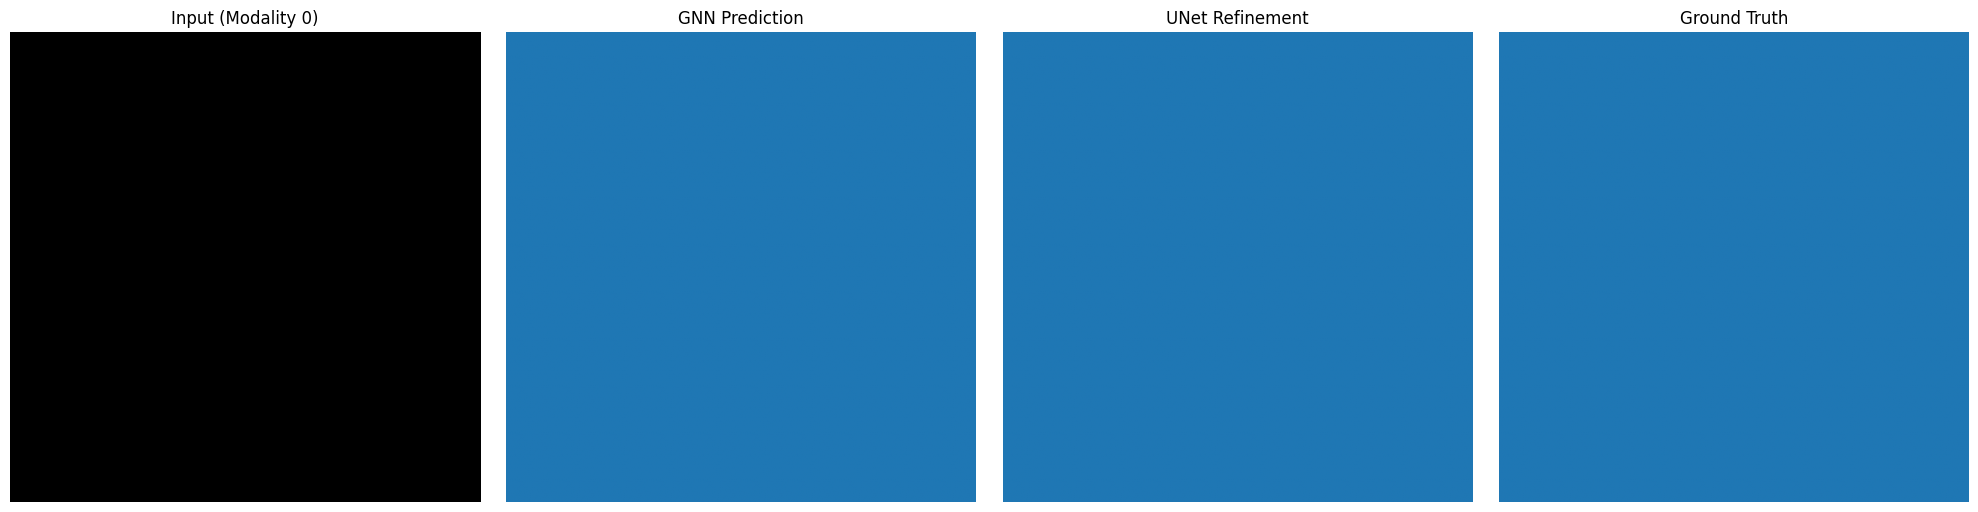


 Processing Slice 2/930


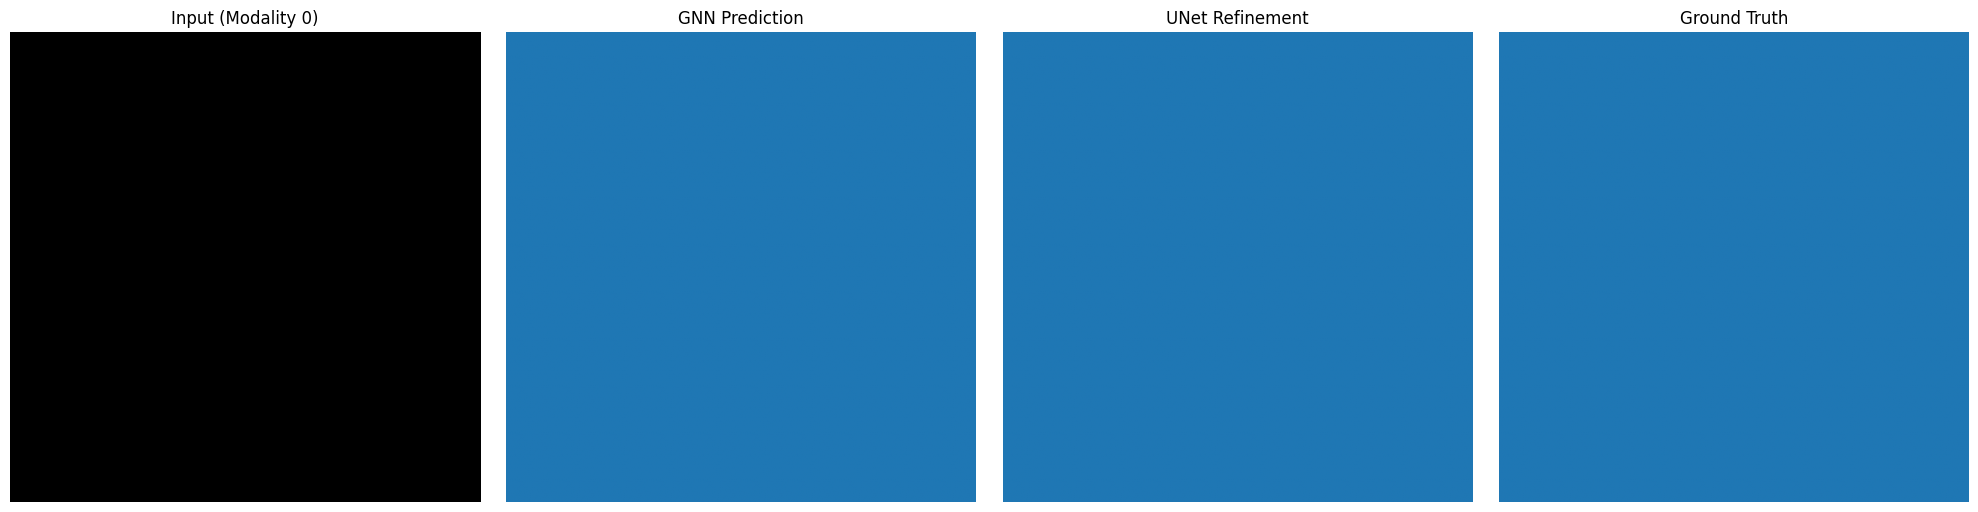


 Processing Slice 3/930


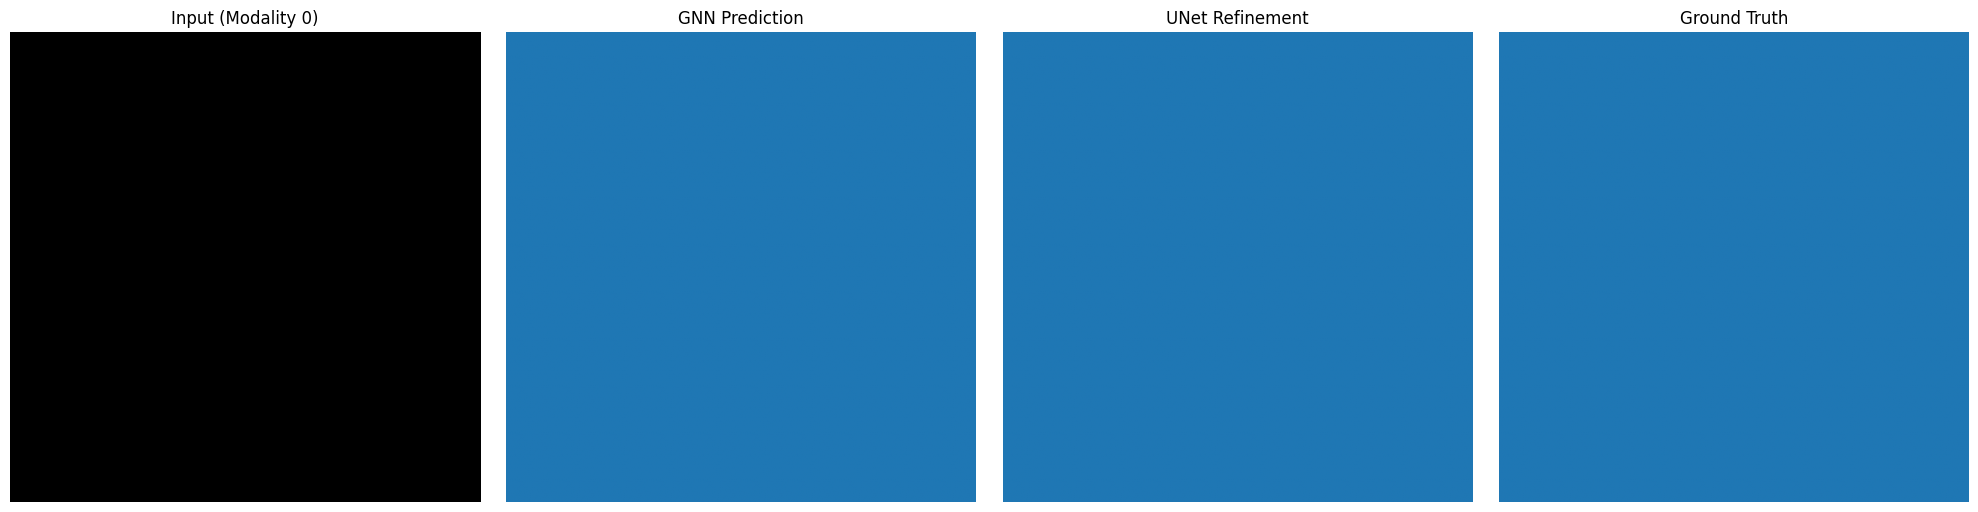


 Processing Slice 4/930


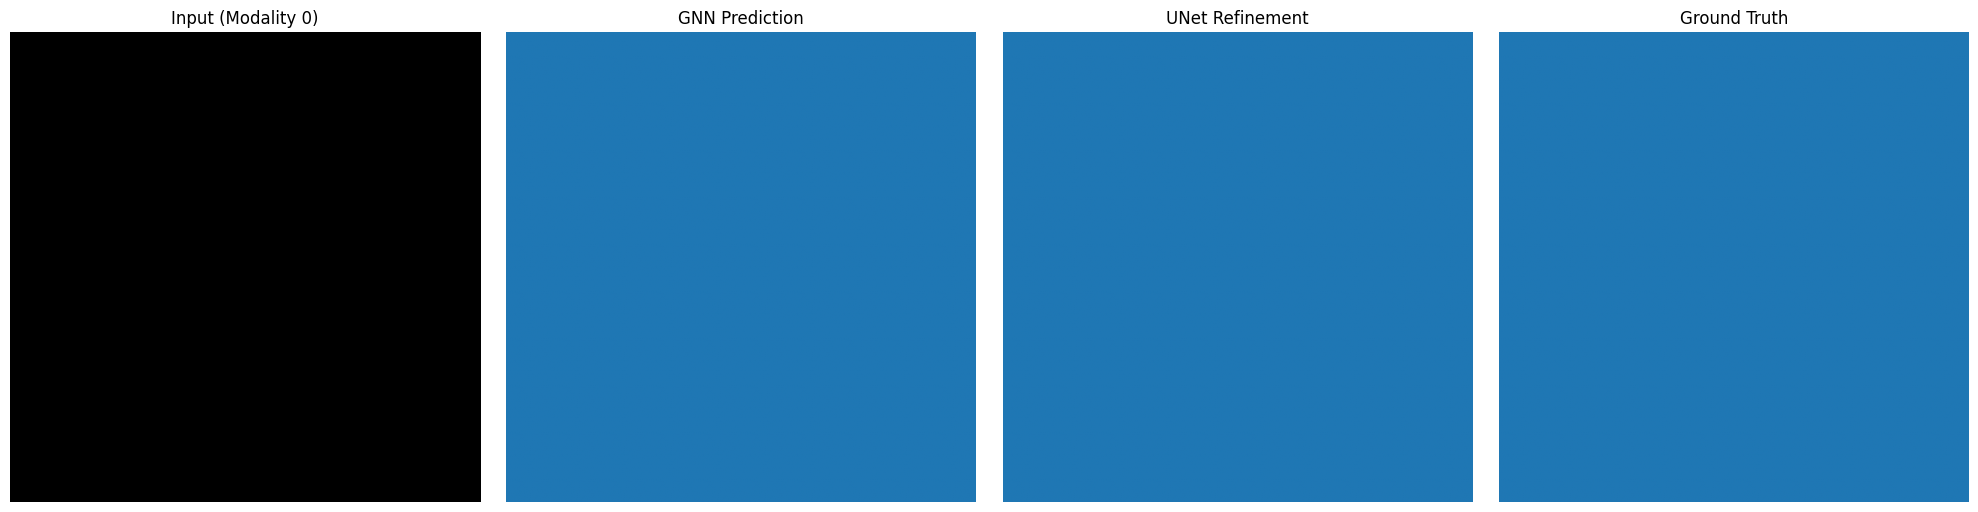


 Processing Slice 5/930


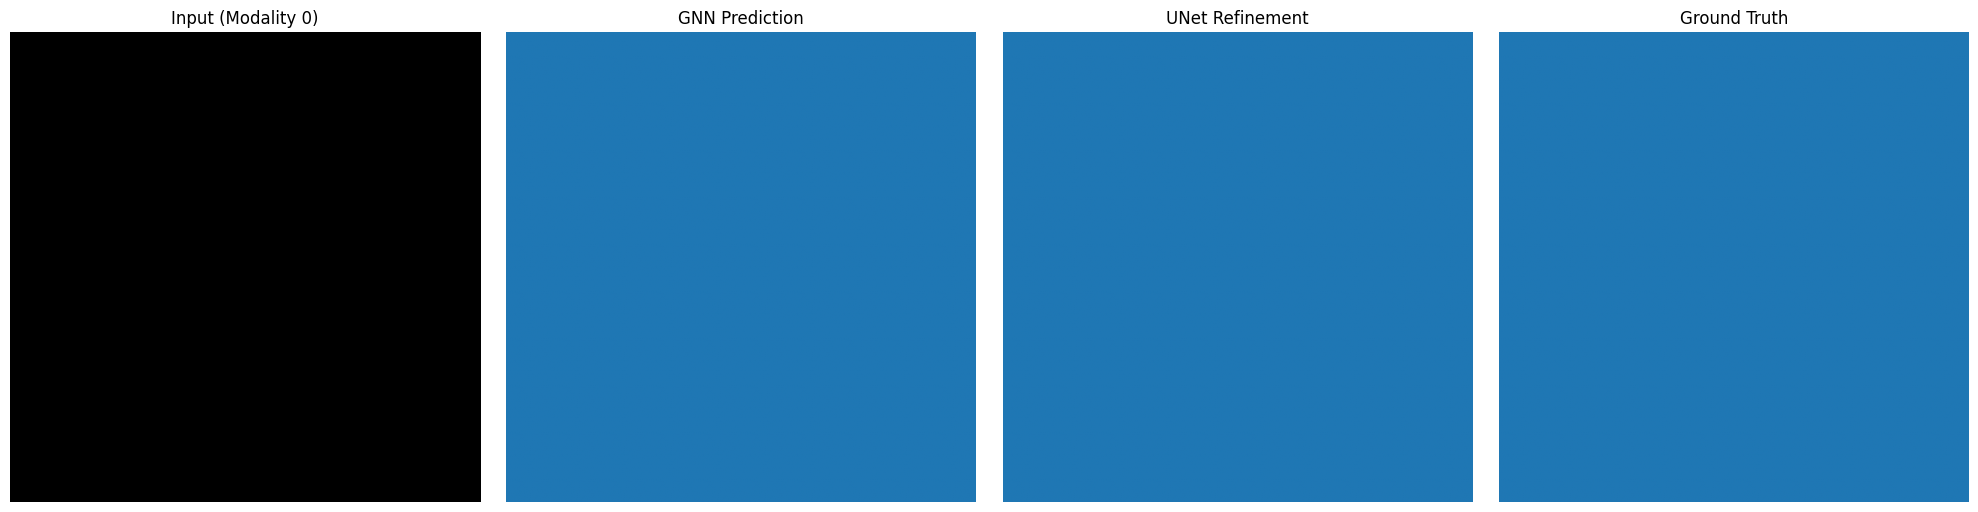


 Processing Slice 6/930


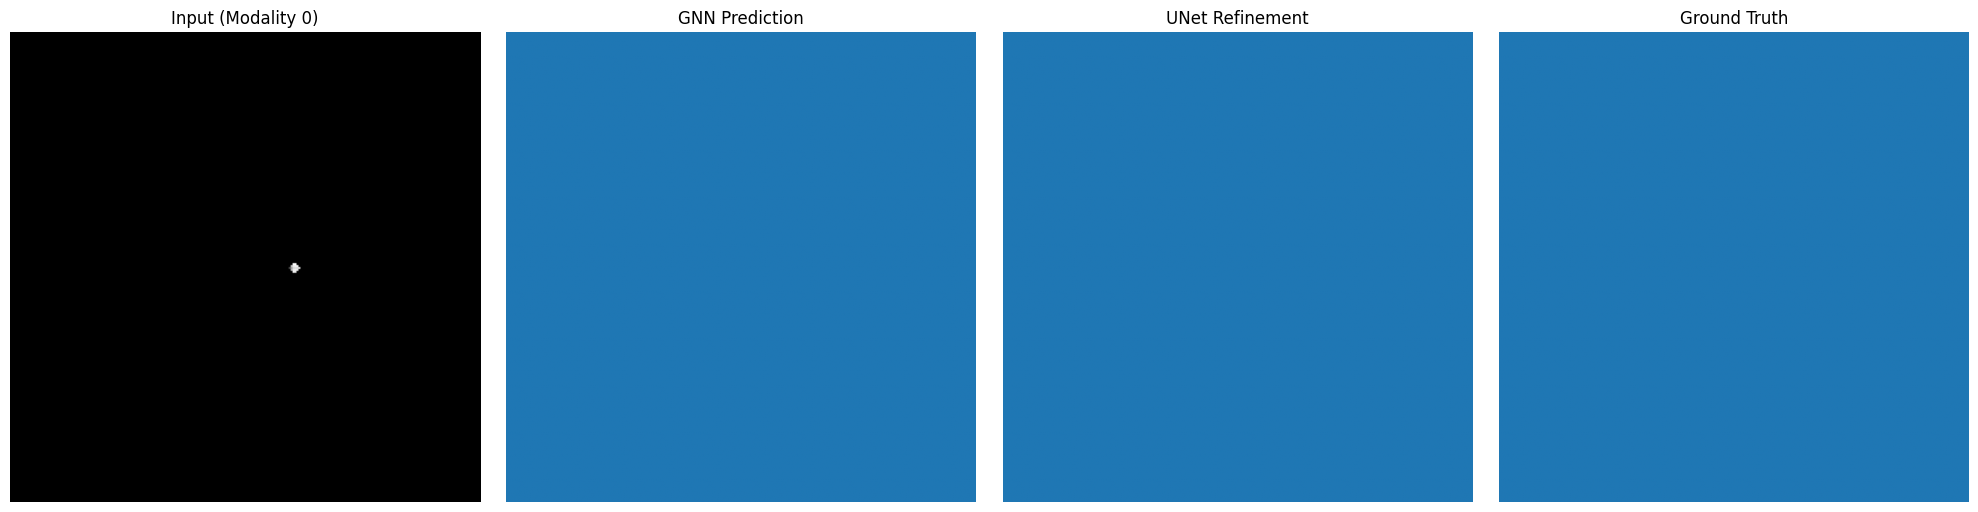


 Processing Slice 7/930


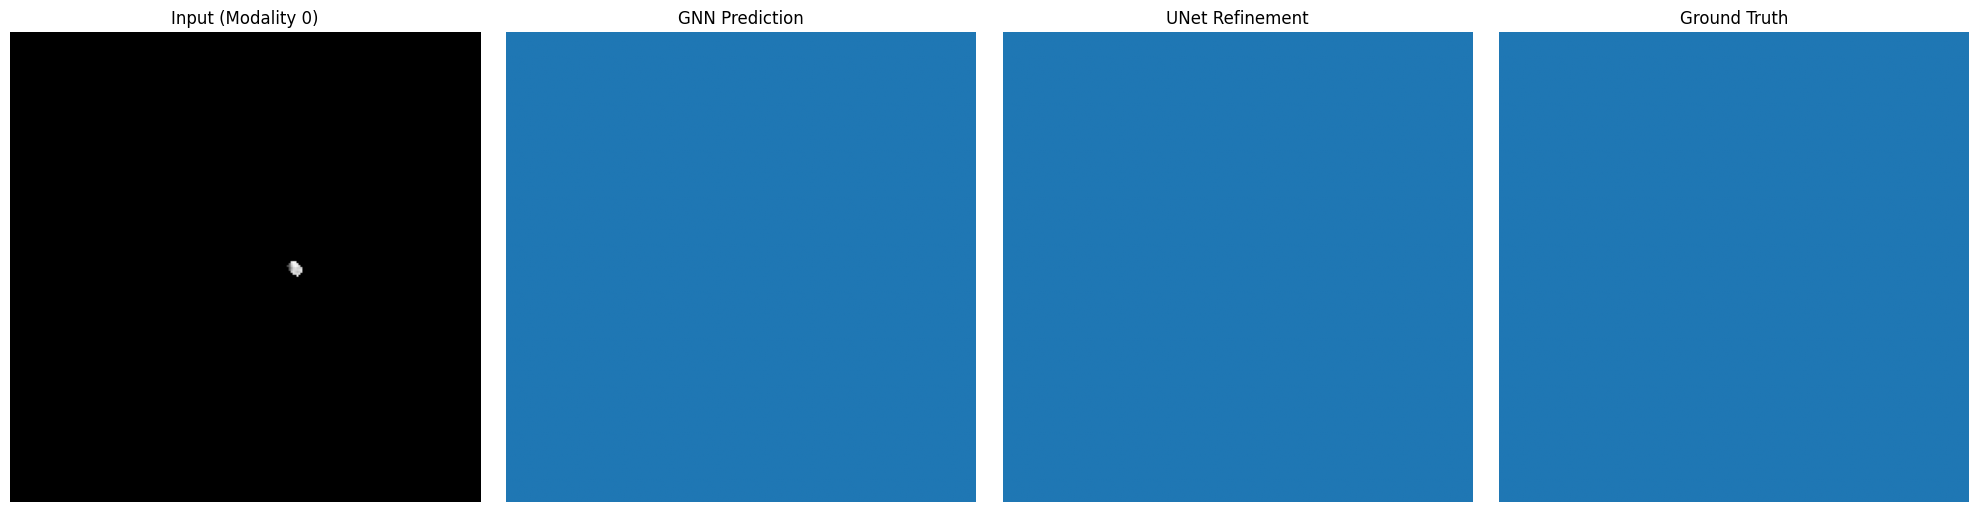


 Processing Slice 8/930


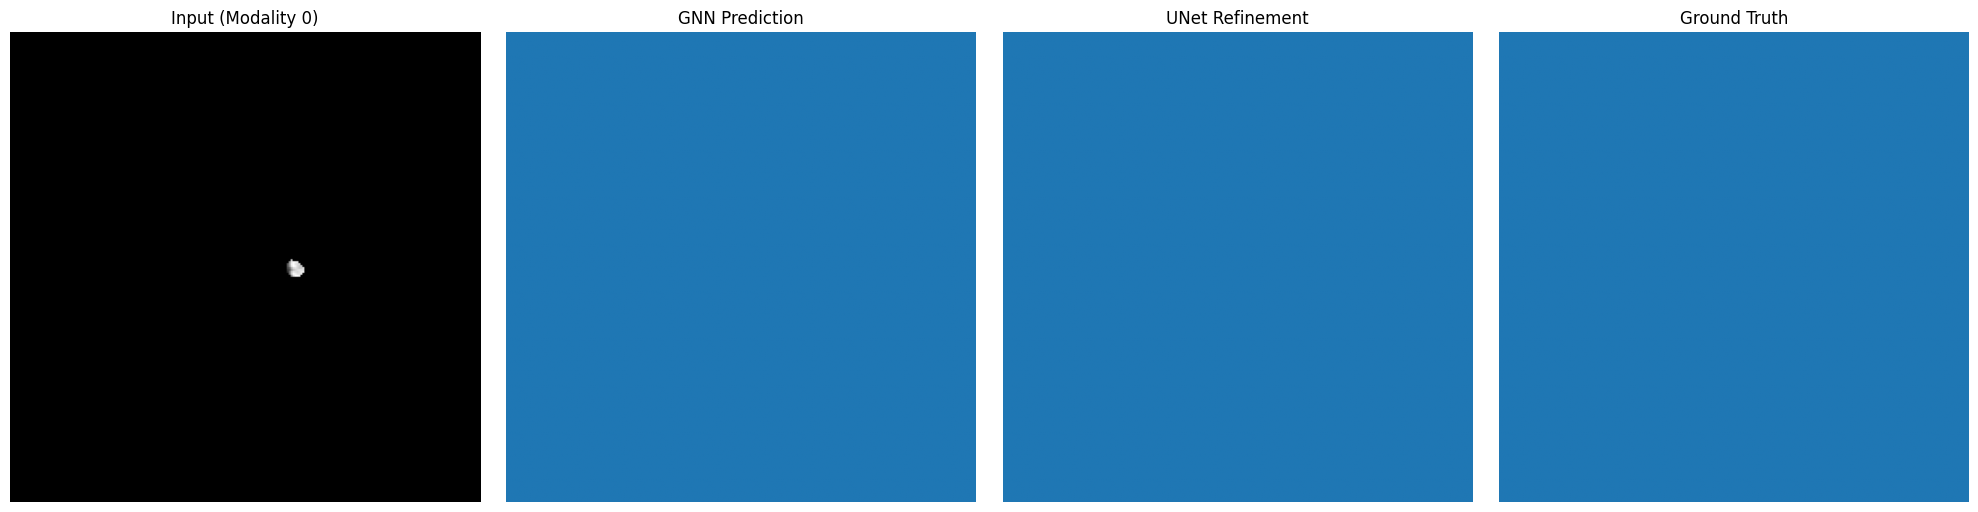


 Processing Slice 9/930


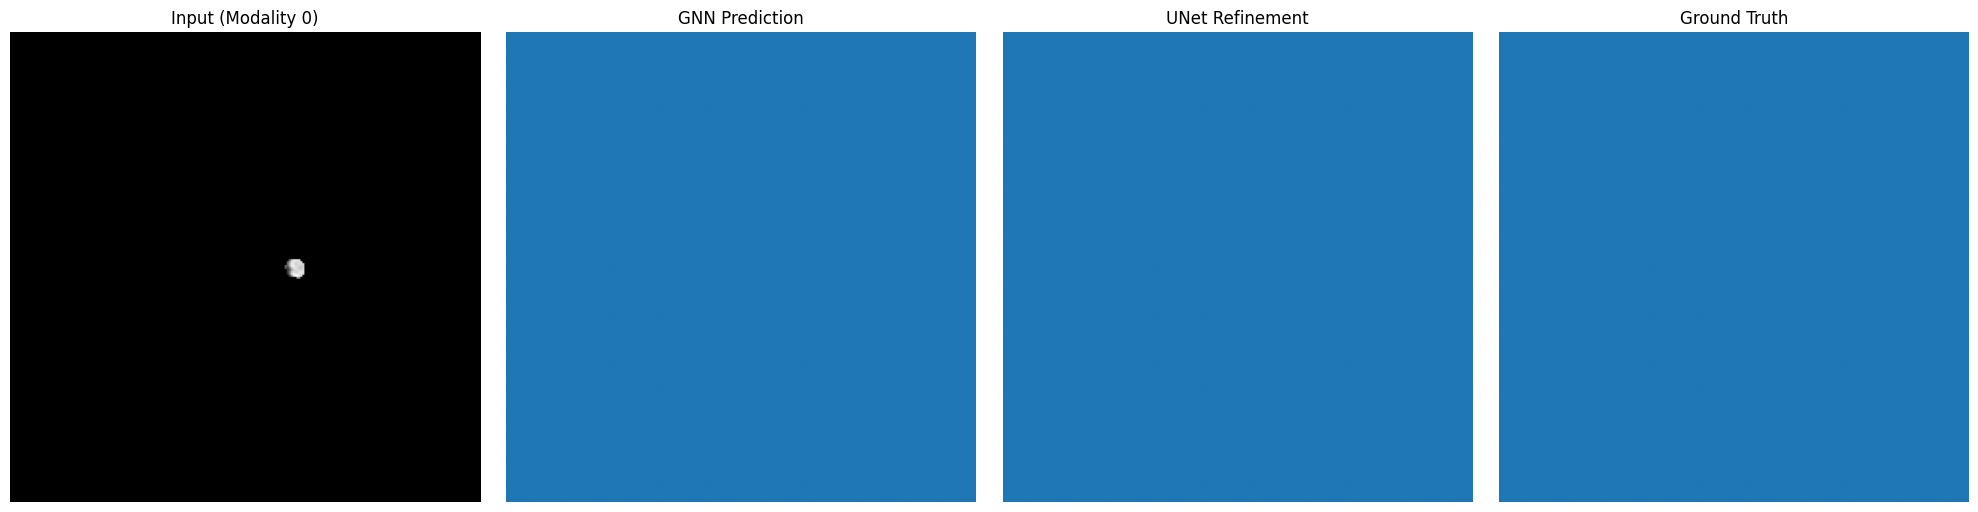


 Processing Slice 10/930


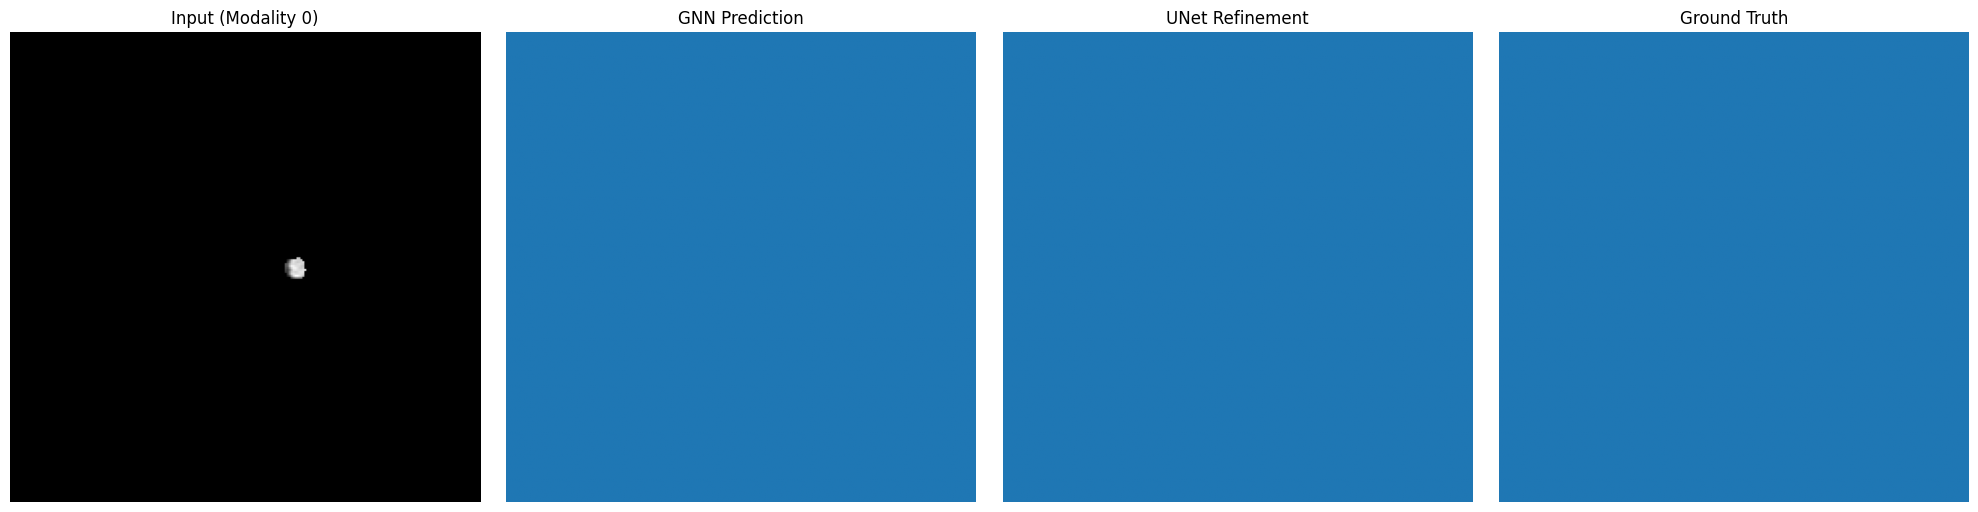


 Processing Slice 11/930


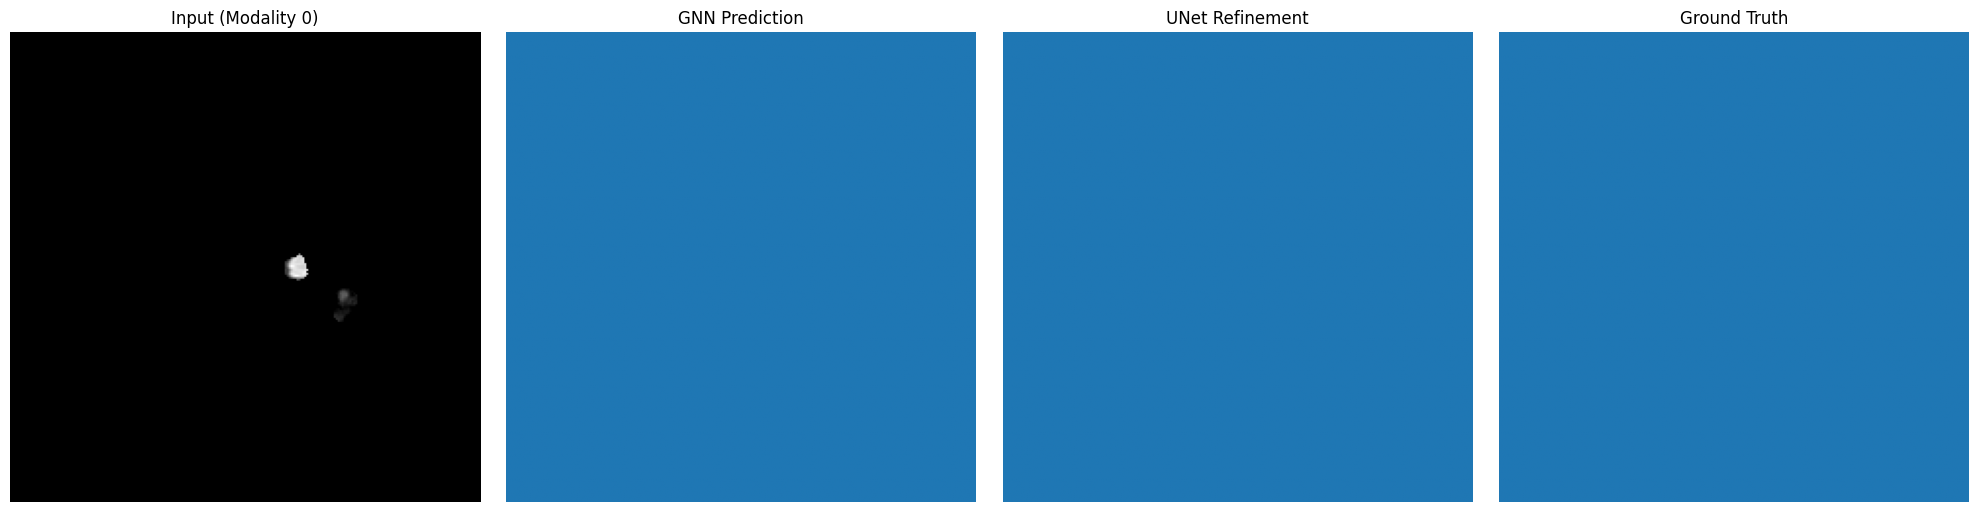


 Processing Slice 12/930


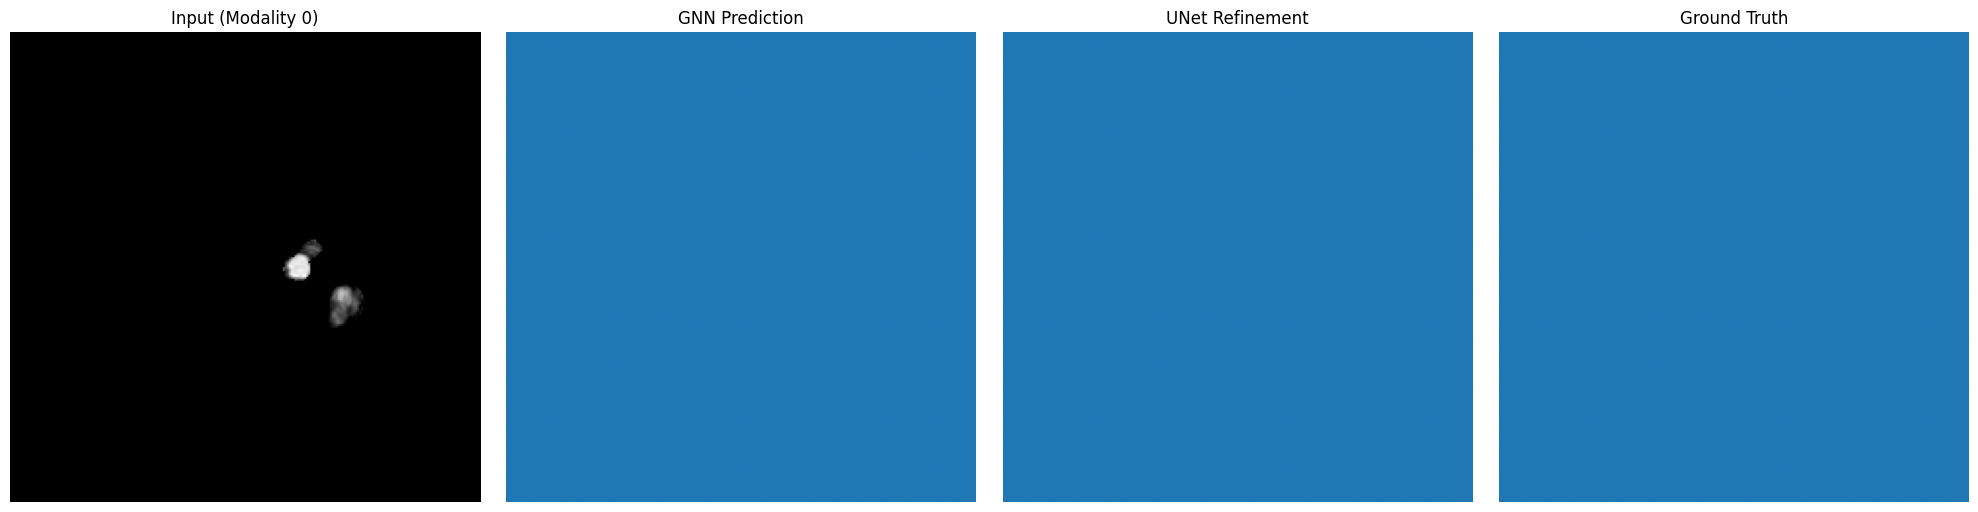


 Processing Slice 13/930


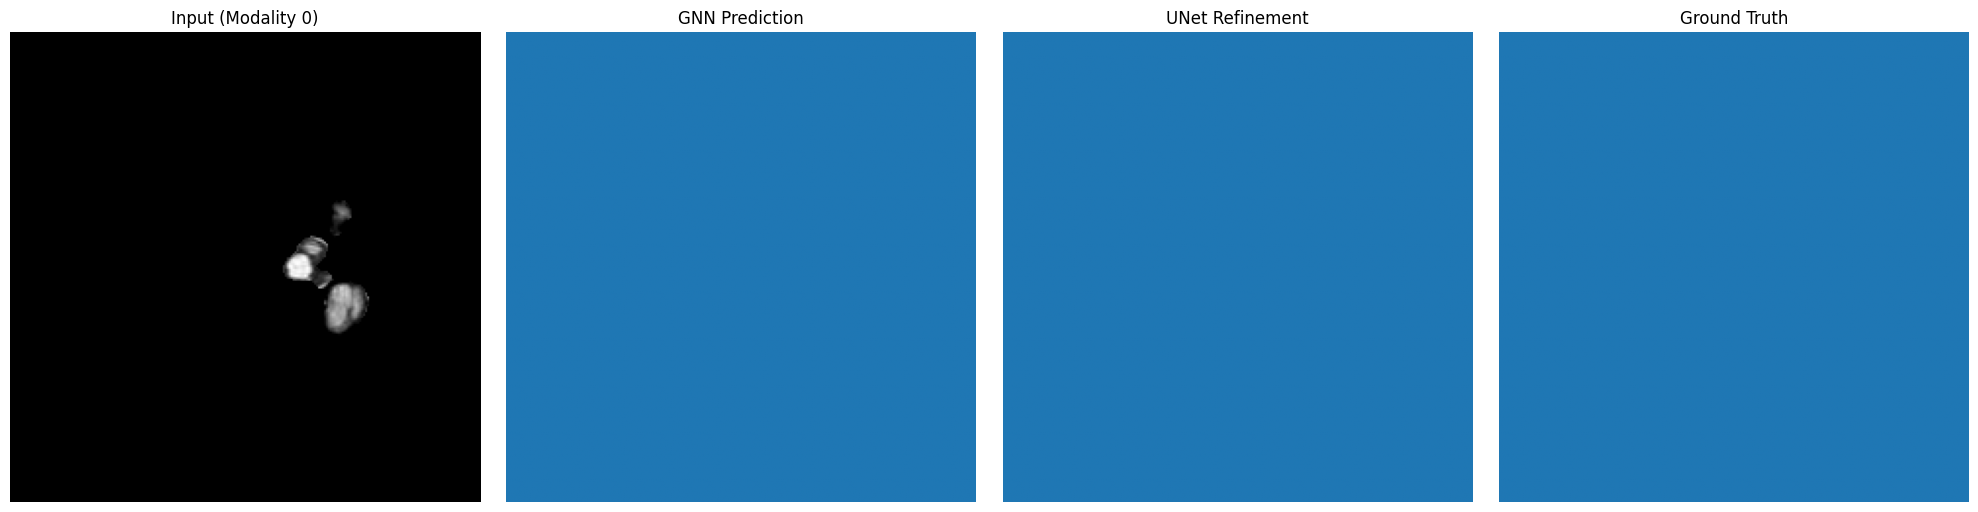


 Processing Slice 14/930


KeyboardInterrupt: 

In [33]:
for i in range(len(test_dataset)):
    print(f"\n Processing Slice {i+1}/{len(test_dataset)}")
    
    sample_image, sample_gt = test_dataset[i]  # [4, H, W], [H, W]
    
    try:
        mask_gnn, mask_unet = visualize_full_pipeline(
            image_slice=sample_image.numpy(),  # input to GNN
            gt_mask=sample_gt.numpy(),         # ground truth
            gnn_model=gnn_model,
            unet_model=unet,
            device=device,
            show=True  # If you want matplotlib plots directly inside this loop
        )
    except Exception as e:
        print(f" Failed on slice {i}: {e}")
